In [1]:
import torch
import matplotlib.pyplot as plt
import json
import numpy as np
import pandas as pd

In [3]:
with open("/nfs/turbo/lsa-tewaria/sahana/greedy/poisson/checkpoints/lstmrouter_s_scheduledsampling_300_iters_4_Helmholtz_Periodic_2d_1c_gsargs.json", "rb") as f:
    loaded = json.load(f)
for k, v in loaded.items():
    print(f"{k}: {v}")

model_type: LSTM
hidden_dim: 256
num_layers: 3
max_iters: 300
dropout: 0.0
batch_size: 32
learning_rate: 0.001
weight_decay: 0.005
warmup_epochs_es: 1
patience: 10000
min_delta: 1e-09
starting_teacher_forcing_prob: 1.0
ending_teacher_forcing_prob: 0.0
decay: 0.95
warmup_epochs_ss: 10
starting_bptt: 30
linear_growth: 1.25
linear: 0
freq: 1
epochs: 300
max_norm: 1.0
N: 33
n_train: 64
n_val: 32


In [2]:
# ckp_path = "/nfs/turbo/lsa-tewaria/sahana/greedy/poisson/checkpoints/lstmrouter_s_scheduledsampling_300_iters_128_Helmholtz_Periodic_2d_1c_mg_full.pth"
solvers = "jacobi" # "jacobi_0.5,jacobi_0.67,jacobi_0.75,jacobi_0.8,jacobi"#,jacobi,jacobi_0.8"
#,jacobi_0.75,jacobi_0.67"
# jacobi,jacobi_0.8,jacobi_0.75,jacobi_0.67
# ckp_path = f"/nfs/turbo/lsa-tewaria/sahana/greedy/poisson/checkpoints/deeponet_msealphaepsilon_loss_new_data4_Poisson_Dirichlet_1d_1c_full.pth"
ckp_path = f"/nfs/turbo/lsa-tewaria/sahana/greedy/poisson/checkpoints/lstmrouter_trying_something_Poisson_Dirichlet_1d_1c_{solvers}_full.pth"

# solvers = "jacobi_0.5,jacobi_0.67,jacobi_0.75,jacobi_0.8,jacobi"
# ckp_path = f"/nfs/turbo/lsa-tewaria/sahana/greedy/poisson/checkpoints/lstmrouter_test_2_sample_100_iters_Poisson_Periodic_1d_1c_{solvers}_full.pth"
# ckp_path = "/nfs/turbo/lsa-tewaria/sahana/greedy/poisson/checkpoints/deeponet_msealphaepsilon_loss_Poisson_Periodic_1d_1c_full.pth"
ckp = torch.load(ckp_path, map_location = "cpu", weights_only=False)

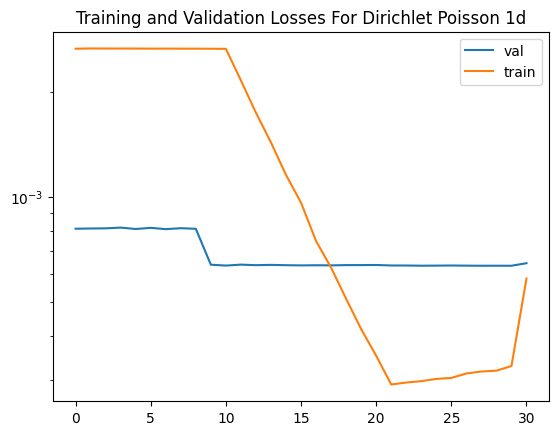

In [3]:
plt.plot(ckp["val_losses"][ckp["val_losses"] != 0], label="val")
plt.plot(ckp["train_losses"][ckp["train_losses"] != 0], label = "train")
plt.title("Training and Validation Losses For Dirichlet Poisson 1d")
plt.yscale("log")
plt.legend()

In [4]:
print(f"{ckp["train_losses"][ckp["val_losses"] != 0][-1]}")
print(f"{ckp["val_losses"][ckp["val_losses"] != 0][-1]}")
print(f"{torch.nanquantile(ckp["val_losses"][ckp["val_losses"] != 0], 0)}")

0.0005841952515766025
0.0006461787270382047
0.0006354603683575988


In [ ]:
error